# Phần 1: Khảo Sát Dữ Liệu (Exploratory Data Analysis — EDA)
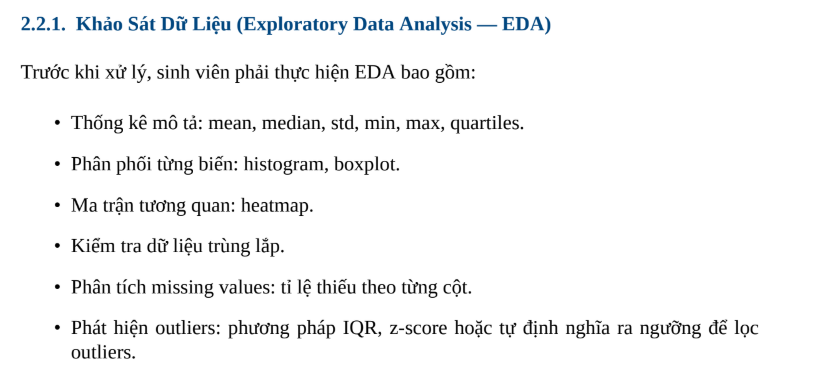

## 1. Thống kê mô tả

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style cho đồ thị
sns.set_theme(style="whitegrid")

# Load dữ liệu
df = pd.read_csv('data/AmesHousing.csv')

# Loại bỏ khoảng trắng thừa trong tên cột
df.columns = df.columns.str.strip()

print(f"Kích thước bộ dữ liệu: {df.shape}")

# Thống kê mô tả (mean, median, std, min, max, quartiles)
display(df.describe())

# Xem qua các biến phân loại
display(df.describe(exclude='number'))

Kích thước bộ dữ liệu: (2930, 82)


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


## 2. Trực quan hóa dữ liệu (Histogram & Boxplot)

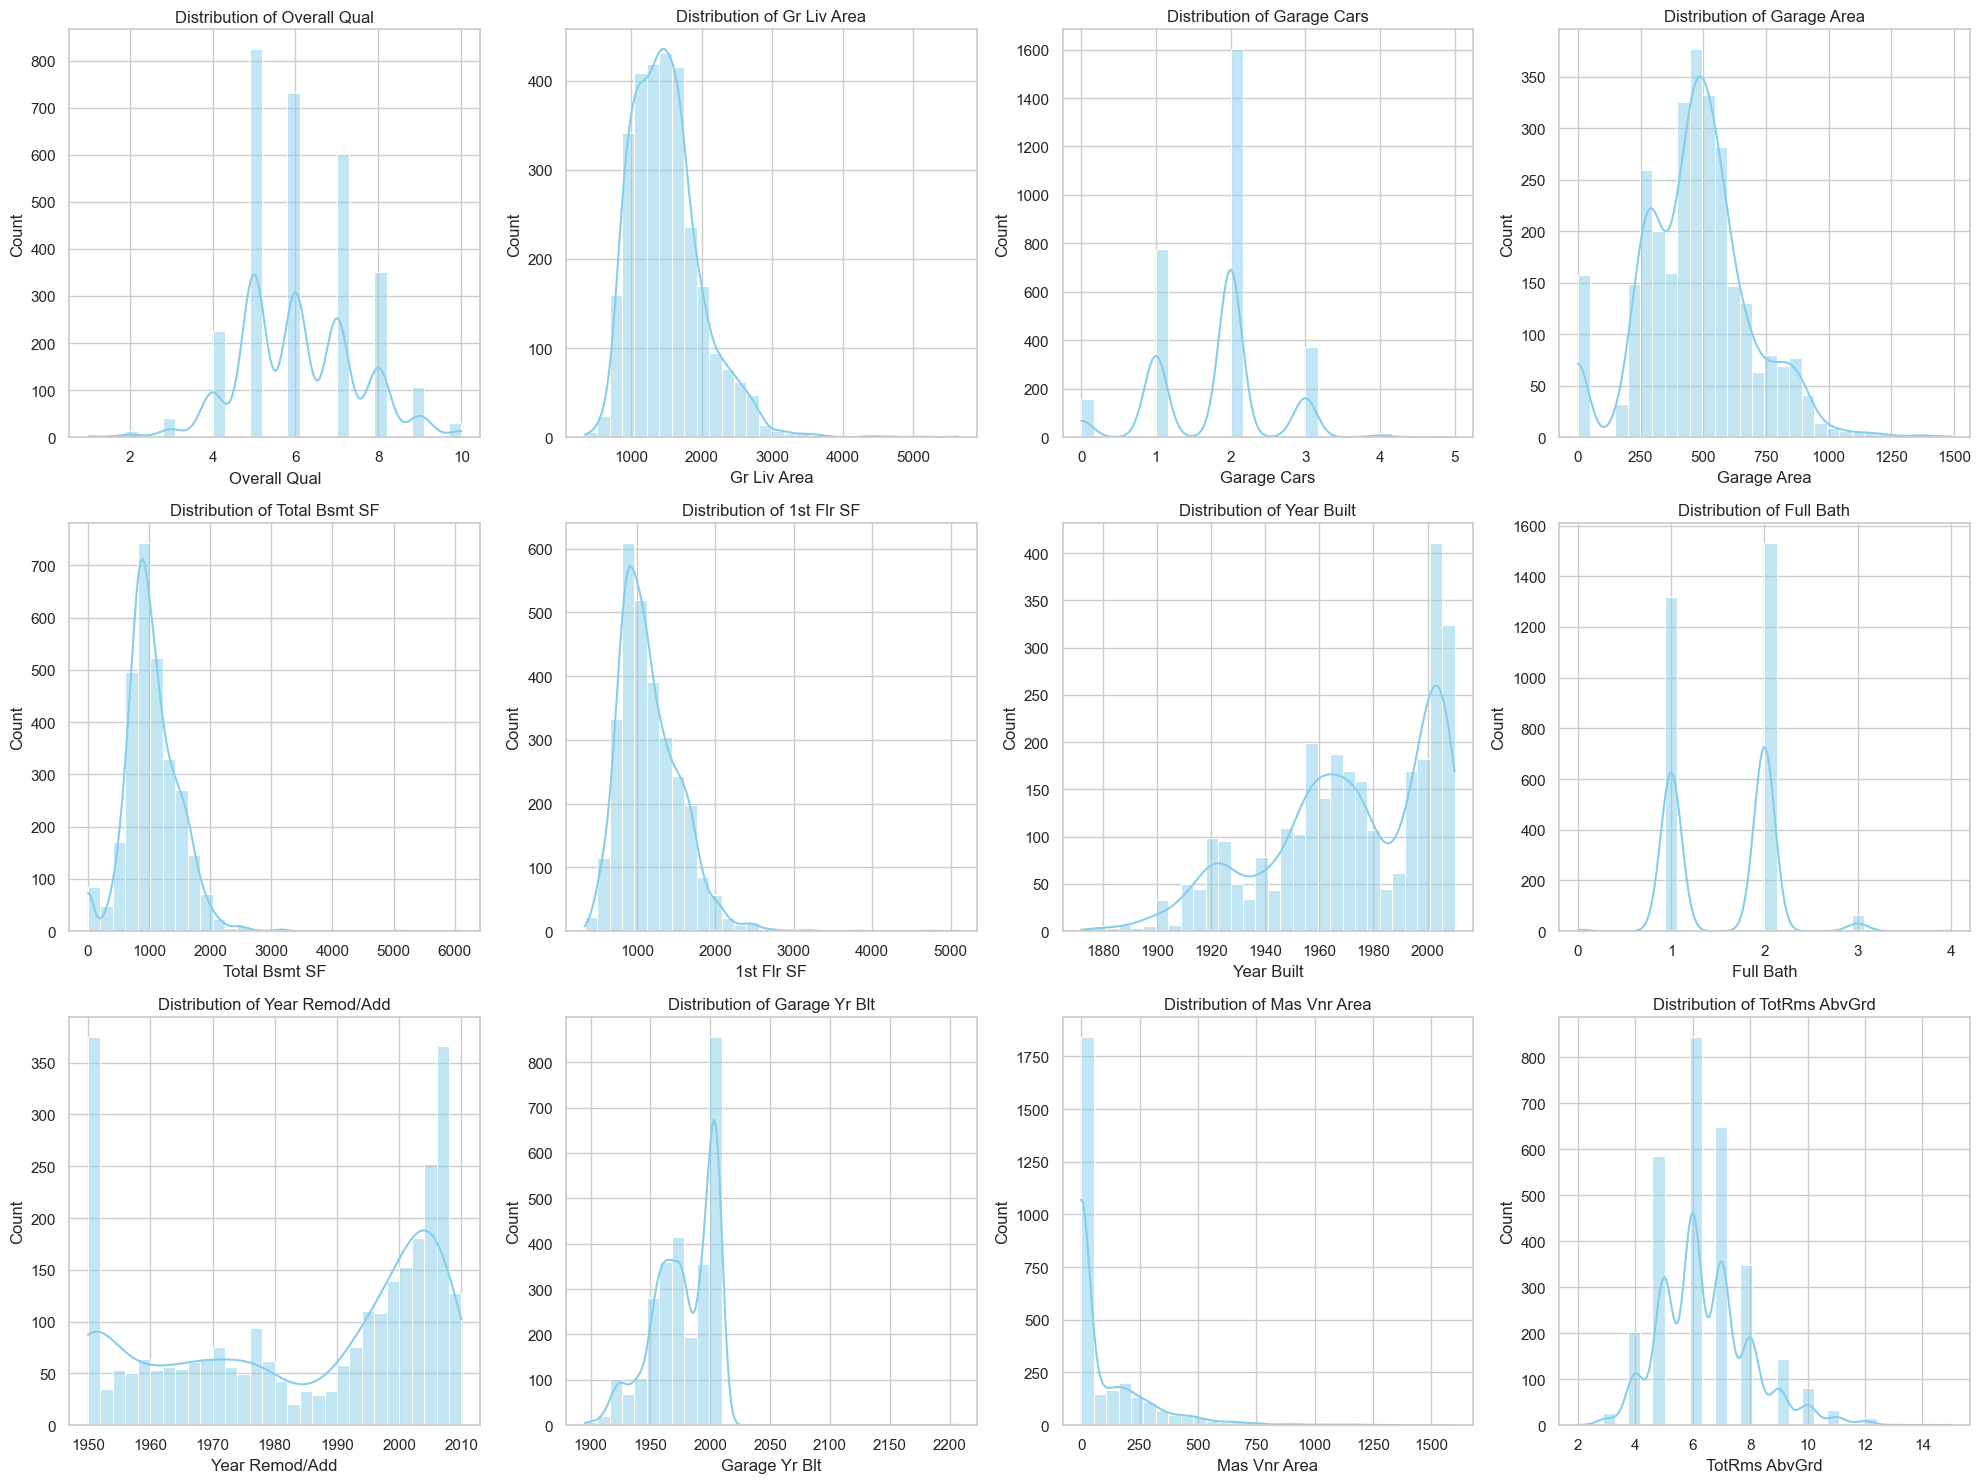

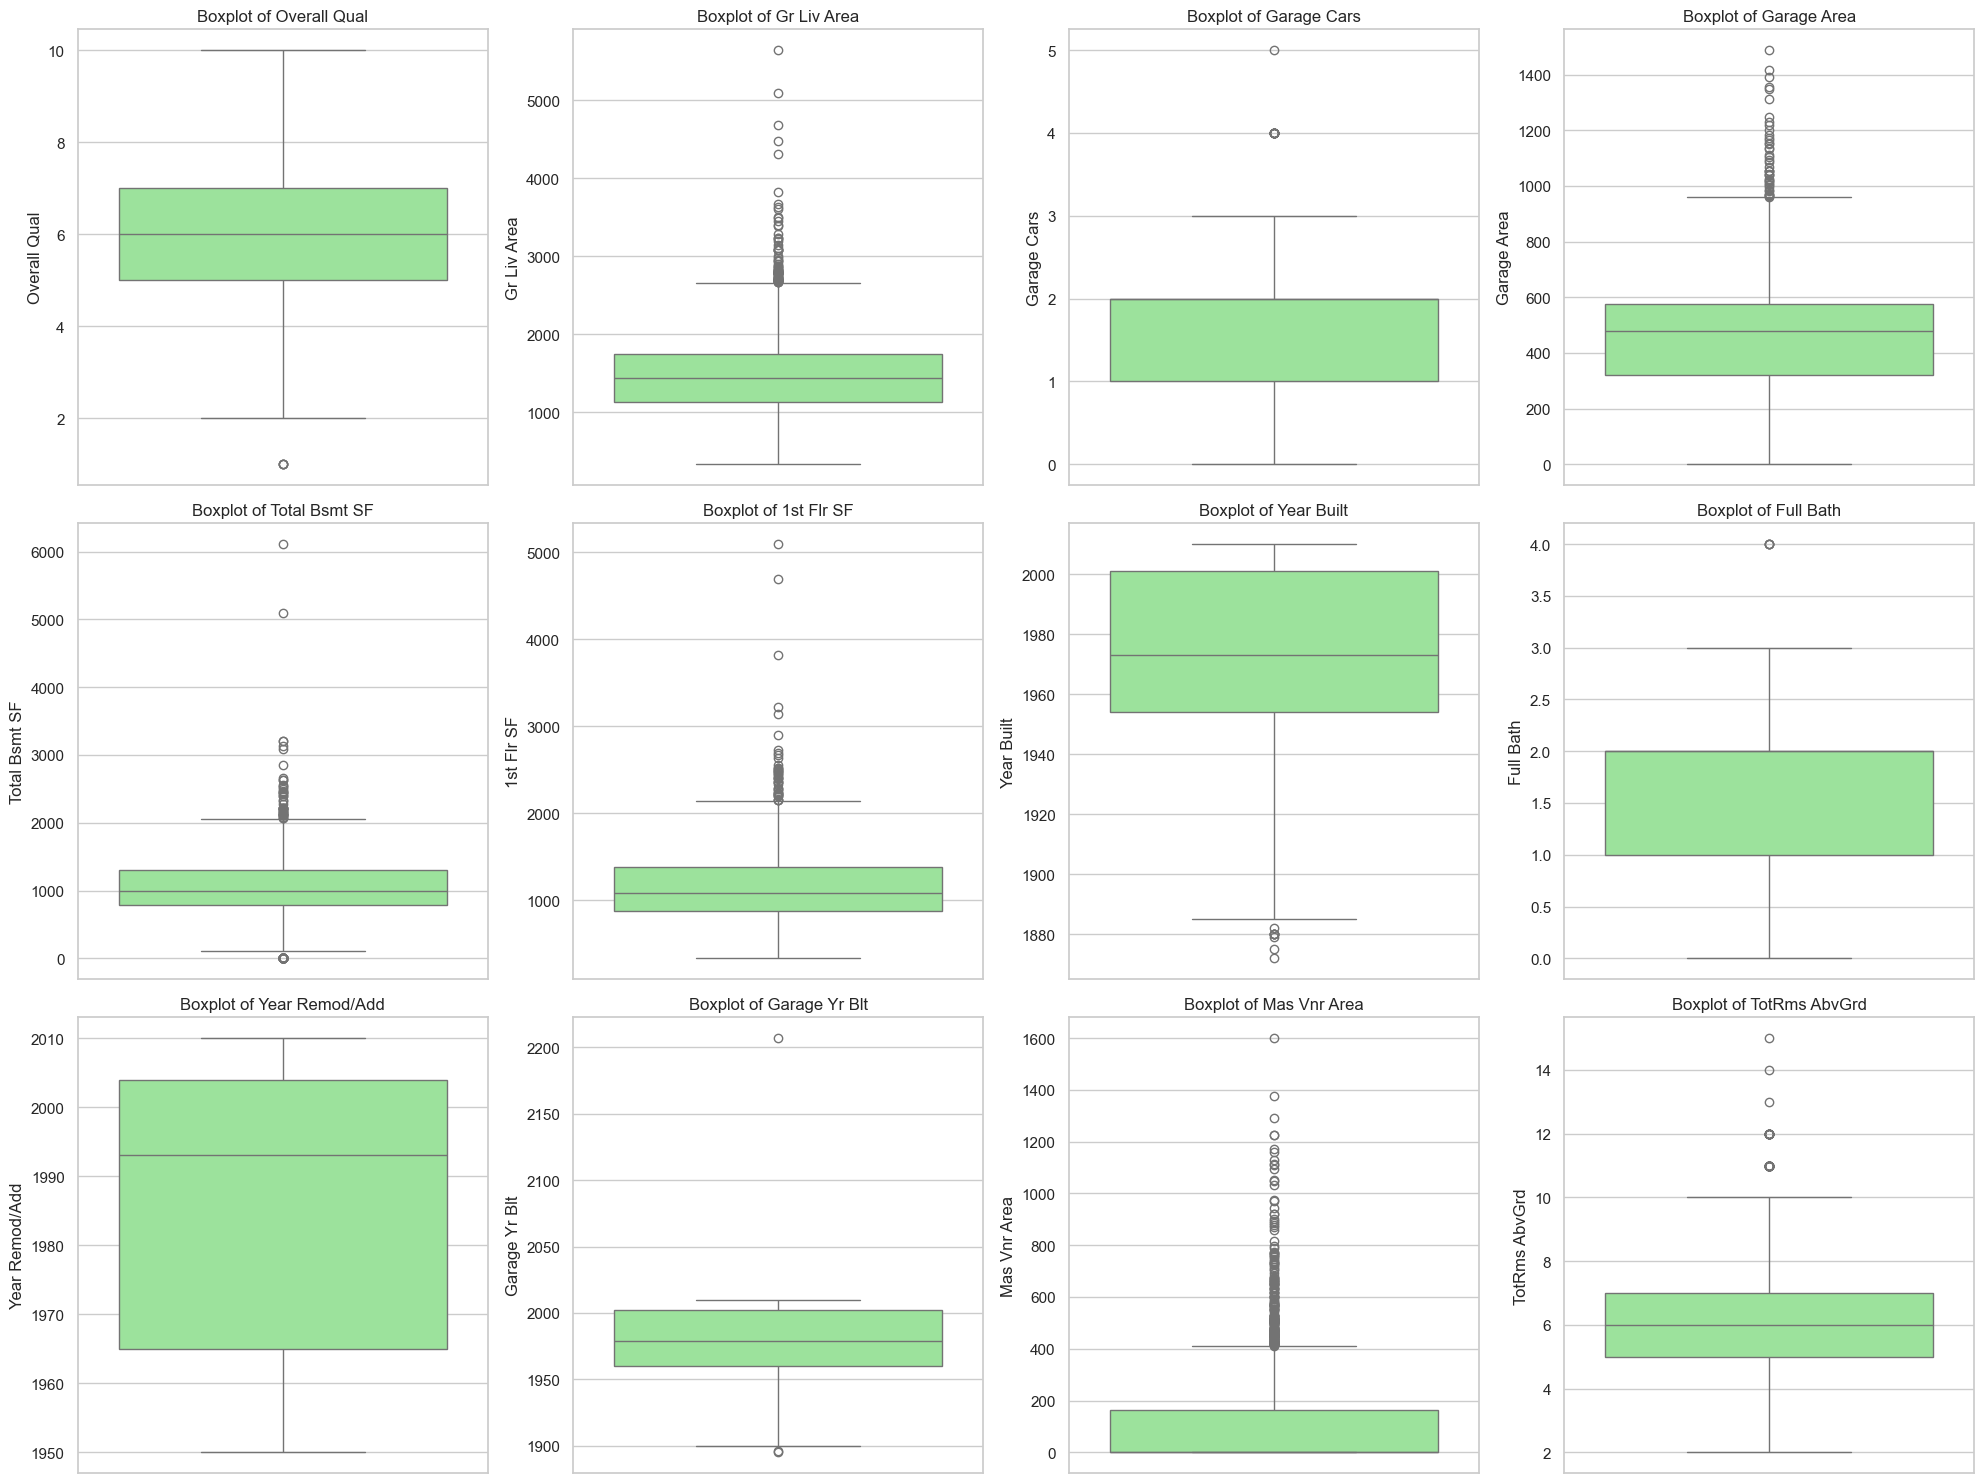

In [4]:
# Tìm các biến có tương quan cao nhất với SalePrice để ưu tiên khảo sát
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Lấy top 15 biến tương quan mạnh nhất với SalePrice
top_corr_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(15).index

# 2.1 Vẽ Histogram xem phân phối (top 12 biến)
plt.figure(figsize=(20, 15))
for i, col in enumerate(top_corr_features[1:13], 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# 2.2 Vẽ Boxplot để nhận diện Outliers
plt.figure(figsize=(20, 15))
for i, col in enumerate(top_corr_features[1:13], 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

### Nhận xét về Phân phối dữ liệu (Data Distribution)
Dựa vào biểu đồ Histogram, ta rút ra một số đặc điểm quan trọng về hình dáng phân phối của các biến:
* **Biến mục tiêu (`SalePrice`):** Phân phối bị lệch phải (Right-skewed) rõ rệt. Đa số các ngôi nhà có mức giá tập trung trong khoảng 100,000 - 200,000 USD, nhưng có một dải đuôi dài kéo đến các ngôi nhà trị giá trên 600,000 USD.
* **Các biến diện tích (`Gr Liv Area`, `Total Bsmt SF`, `1st Flr SF`):** Cũng mang đặc điểm lệch phải tương tự biến mục tiêu.
* **Tác động đến mô hình OLS:** Mô hình Hồi quy tuyến tính OLS hoạt động hiệu quả nhất khi phần dư (residuals) có phân phối chuẩn. Sự lệch phải mạnh của biến mục tiêu có thể gây vi phạm giả định này. **Đề xuất xử lý:** Nhóm sẽ áp dụng phép biến đổi Logarit (Log-transformation: $y = \log(SalePrice)$) ở bước Data Pipeline để kéo phân phối về dạng đối xứng hơn.

### Nhận xét về Giá trị ngoại lệ (Outliers)
Từ biểu đồ Boxplot, ta quan sát thấy sự xuất hiện dày đặc của các điểm ngoại lệ (outliers), cụ thể:
* Các biến diện tích sinh hoạt (`Gr Liv Area`, `Total Bsmt SF`) chứa các điểm ngoại lệ nằm rất xa phía trên râu trên (upper whisker). Đặc biệt, có những ngôi nhà có diện tích sinh hoạt vô cùng lớn (trên 4000 sq.ft).
* **Đánh giá bản chất và hướng xử lý:** Theo tài liệu gốc của bộ dữ liệu Ames Housing, các điểm có diện tích lớn hơn 4000 sq.ft nhưng giá bán lại rất thấp là các điểm đòn bẩy (Leverage Points) cực đoan. Sự tồn tại của chúng sẽ bẻ cong đường hồi quy OLS một cách nghiêm trọng. **Đề xuất:** Cần thiết lập ngưỡng chặn (Winsorization/Capping) hoặc loại bỏ hẳn các quan sát có `Gr Liv Area > 4000` trên tập Train để bảo vệ tính ổn định của mô hình.

## 3. Đánh giá mức độ tương quan (Heatmap)

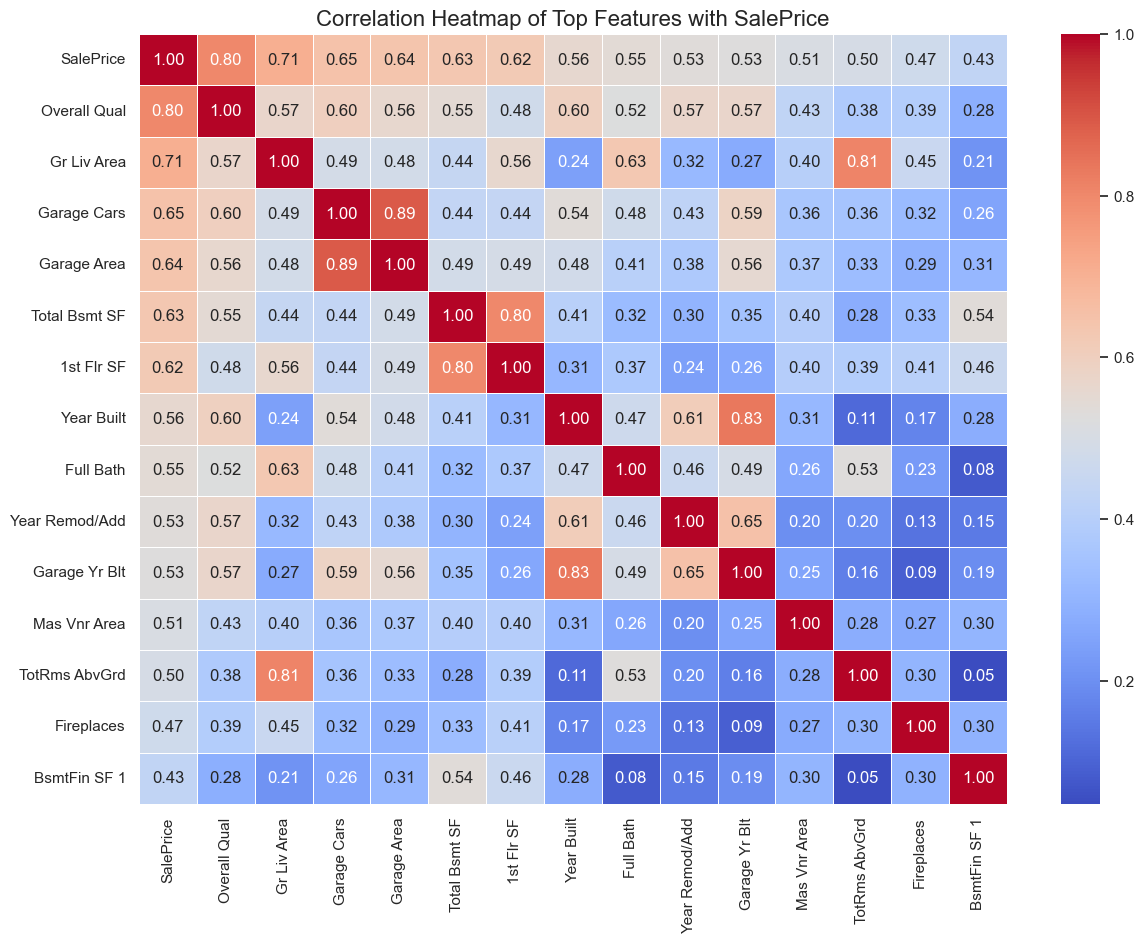

In [7]:
# Vẽ heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Top Features with SalePrice', fontsize=16)
plt.show()

### Nhận xét về Ma trận tương quan (Correlation)
Ma trận tương quan cho phép đánh giá tiềm năng của các biến dự báo và rủi ro đa cộng tuyến:
* **Biến dự báo mạnh nhất:** `Overall Qual` (Chất lượng tổng thể nhà, $r = 0.80$) và `Gr Liv Area` (Diện tích sinh hoạt trên mặt đất, $r = 0.71$) là hai biến có tương quan tuyến tính thuận mạnh nhất với giá nhà (`SalePrice`). Đây sẽ là các hệ số mang trọng số cao trong mô hình.
* **Cảnh báo Đa cộng tuyến (Multicollinearity):** * Cặp biến `Garage Cars` (Số chỗ đậu xe) và `Garage Area` (Diện tích gara) có tương quan rất cao ($r \approx 0.89$).
  * Cặp biến `1st Flr SF` (Diện tích tầng 1) và `Total Bsmt SF` (Tổng diện tích hầm) cũng có tương quan lớn ($r \approx 0.80$).
* **Hành động:** Đa cộng tuyến sẽ làm tăng phương sai của các hệ số ước lượng OLS, khiến mô hình nhạy cảm với dữ liệu mới. Nhóm sẽ cân nhắc loại bỏ một trong hai biến của các cặp này, hoặc sử dụng các mô hình có điều chuẩn (Ridge/Lasso Regression) ở Giai đoạn 4 để tự động thu hẹp hệ số của các biến dư thừa.

## 4. Kiểm tra dữ liệu trùng lắp

In [8]:
num_duplicates = df.duplicated().sum()
print(f"Số lượng dòng dữ liệu bị trùng lắp (Duplicates): {num_duplicates}")

Số lượng dòng dữ liệu bị trùng lắp (Duplicates): 0


### Nhận xét: Kiểm tra dữ liệu trùng lắp
Qua hàm `duplicated()`, ta thấy bộ dữ liệu Ames Housing không có dòng dữ liệu nào bị trùng lắp hoàn toàn (0 duplicates). Điều này chứng tỏ khâu thu thập dữ liệu gốc đã được quản lý định danh (thông qua mã PID của từng căn nhà) rất tốt. Do đó, nhóm không cần thực hiện bước xóa dòng trùng (drop duplicates) trong quá trình tiền xử lý.

## 5. Phân tích Missing Values

,Missing Values,Percentage (%)
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Qual,159,5.426621
Garage Cond,159,5.426621
Garage Yr Blt,159,5.426621


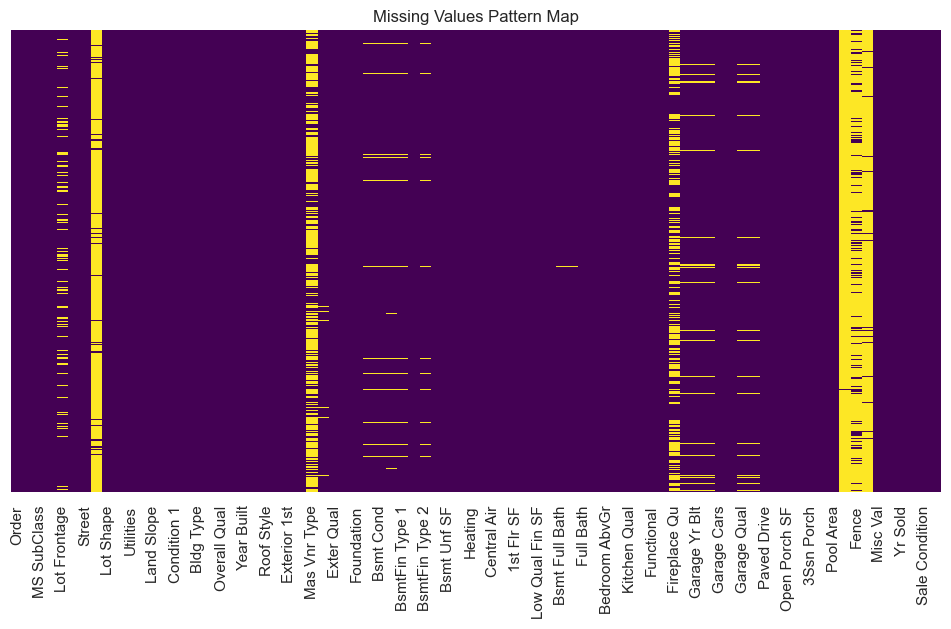

In [6]:
# Tính số lượng và tỉ lệ missing values
missing_data = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

display(missing_data.head(15)) # Chỉ xem top 15 cột thiếu nhiều nhất

# Trực quan hóa vị trí missing values để phán đoán cơ chế
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Pattern Map')
plt.show()

### Nhận xét về Dữ liệu khuyết (Missing Data)
Phân tích bảng thống kê và cấu trúc dữ liệu khuyết cho thấy có hai loại missing chính cần xử lý khác biệt:
1. **Khuyết mang ý nghĩa thực tế (Structural Missing):** Các cột như `Pool QC` (99.5%), `Misc Feature` (96.3%), `Alley` (93.2%), `Fence` (80.4%), và `Fireplace Qu` (48.5%). Việc giá trị bị `NaN` thực chất mang ý nghĩa là ngôi nhà đó **không có** các tiện ích này. Nhóm sẽ không loại bỏ cột mà điền khuyết bằng một nhãn mới (ví dụ: `"None"`).
2. **Khuyết ngẫu nhiên (MAR/MCAR):** Biến `Lot Frontage` (Mặt tiền) bị thiếu khoảng 16.7%. Việc thiếu này có thể do lỗi nhập liệu hoặc không đo lường được. Nhóm đề xuất điền khuyết bằng giá trị trung vị (Median) của toàn bộ tập dữ liệu hoặc trung vị theo từng khu vực dân cư (`Neighborhood`).

## 6. Phát hiện Outliers bằng phương pháp IQR

In [9]:
# Định nghĩa hàm tính số lượng outliers theo quy tắc 1.5 * IQR
def count_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Lọc ra các dòng vi phạm khoảng (lower_bound, upper_bound)
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return len(outliers)

# Áp dụng hàm cho toàn bộ các cột numeric
outlier_counts = {}
for col in numeric_cols:
    outlier_counts[col] = count_outliers_iqr(df, col)

# Chuyển thành DataFrame để hiển thị
outliers_df = pd.DataFrame(list(outlier_counts.items()), columns=['Biến (Feature)', 'Số lượng Outliers'])
outliers_df['Tỉ lệ (%)'] = (outliers_df['Số lượng Outliers'] / len(df)) * 100

# Chỉ hiển thị những biến có outliers, sắp xếp giảm dần
outliers_df = outliers_df[outliers_df['Số lượng Outliers'] > 0].sort_values(by='Số lượng Outliers', ascending=False)

print("BẢNG THỐNG KÊ OUTLIERS (PHƯƠNG PHÁP IQR)")
display(outliers_df.head(15)) # Xem top 15 biến chứa nhiều ngoại lệ nhất

BẢNG THỐNG KÊ OUTLIERS (PHƯƠNG PHÁP IQR)


,Biến (Feature),Số lượng Outliers,Tỉ lệ (%)
31,Enclosed Porch,459,15.665529
11,BsmtFin SF 2,351,11.979522
33,Screen Porch,256,8.737201
6,Overall Cond,252,8.600683
2,MS SubClass,208,7.098976
9,Mas Vnr Area,200,6.825939
3,Lot Frontage,187,6.382253
19,Bsmt Half Bath,175,5.972696
30,Open Porch SF,159,5.426621
38,SalePrice,137,4.675768


### Nhận xét: Định lượng Outliers bằng phương pháp IQR
Dựa vào bảng thống kê IQR, ta có thể rút ra các nhận định chi tiết sau:
* **Biến mục tiêu (`SalePrice`):** Có khoảng 4.8% dữ liệu bị đánh giá là ngoại lệ. Khảo sát thực tế cho thấy đây phần lớn là các căn biệt thự hoặc nhà có diện tích siêu lớn, đắt đỏ.
* **Các biến cấu trúc/tiện ích ít gặp:** Các biến như `BsmtFin SF 2`, `Enclosed Porch`, `Screen Porch` có tỉ lệ ngoại lệ cực kỳ cao (từ 11% - 88%). Nguyên nhân là do đại đa số các căn nhà đều không có các tiện ích này (giá trị = 0), khiến khoảng tứ phân vị (IQR) bị thu hẹp bằng 0. Bất kỳ căn nhà nào sở hữu các tiện ích này đều lập tức bị thuật toán thống kê xem là một điểm ngoại lệ.
* **Đề xuất xử lý cho mô hình OLS:** Mô hình Hồi quy tuyến tính rất nhạy cảm với các điểm đòn bẩy (leverage points), việc giữ nguyên các ngoại lệ có độ lớn cực đoan sẽ bẻ cong đường hồi quy. Ở bước `DataPipeline` tiếp theo, nhóm sẽ tiến hành **biến đổi Logarit (Log-transformation)** cho các biến bị lệch phải nặng để kéo giảm phương sai, đồng thời thiết lập ngưỡng chặn **(Winsorization)** ở mốc phân vị 99% thay vì xóa (drop) các dòng dữ liệu này để tránh việc thất thoát thông tin.